In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral/edge_preservation_analysis.png
/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral/comparison_pipeline.png
/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral/dyed-lifted-polyps/07270b1b-84de-40d2-bbff-698bf3b91512.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral/dyed-lifted-polyps/40f6ef85-0e89-457c-aaae-cabe2bbe47ea.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral/dyed-lifted-polyps/060e78dd-e11f-4ff4-8610-d62277b3381e.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral/dyed-lifted-polyps/3c38d8a9-52d4-415e-b8a2-25fa28d87393.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral/dyed-lifted-polyps/335adfe9-89ea-4ac7-bcba-1fdd4cc844da.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral/dyed-lifted-polyps/23745e74-a557-483f-aed6-beca9e90f303.jpg
/kaggle/input/datasets/sr

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("srabontideb/kvasir-v2-clahe-gaussian-bilateral")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral


In [4]:
# ============================================================
# 0) IMPORTS
# ============================================================
import os, glob, math, gc, json, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.mixed_precision import set_global_policy
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, cohen_kappa_score, matthews_corrcoef,
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

# Mixed precision for speed (beneficial on P100/T4/V100)
set_global_policy("mixed_float16")




In [5]:
# ============================================================
# 1) CONFIGURATION
# ============================================================
class CFG:
    # --- Paths ---
    DATA_DIR    = "/kaggle/input/kvasir-v2-clahe-gaussian-bilateral"  # your uploaded dataset
    OUTPUT_DIR  = "/kaggle/working/convnext_results"

    # --- Image ---
    IMG_SIZE    = (224, 224)

    # --- Training ---
    BATCH_SIZE       = 32
    EPOCHS_WARMUP    = 5        # Phase 1: frozen backbone
    EPOCHS_FINETUNE  = 20       # Phase 2: unfrozen backbone
    LR_WARMUP        = 1e-3
    LR_FINETUNE      = 5e-4
    LABEL_SMOOTHING  = 0.1
    DROPOUT_RATE     = 0.3

    # --- K-Fold ---
    N_SPLITS     = 5
    TEST_SIZE    = 0.15         # held-out test set (never seen during CV)
    RANDOM_STATE = 42

    # --- Auto ---
    AUTOTUNE = tf.data.AUTOTUNE

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)


In [6]:
# ============================================================
# 2) LOAD DATA — Collect all paths + labels
# ============================================================

# Step 1: Find correct path (run !ls /kaggle/input/ to verify)
CFG.DATA_DIR = "/kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral"

def find_data_root(base_path):
    """Auto-detect the folder containing class subfolders."""
    base = Path(base_path)
    known_classes = {"polyps", "esophagitis", "normal-cecum", "ulcerative-colitis",
                     "dyed-lifted-polyps", "dyed-resection-margins", "normal-pylorus", "normal-z-line"}
    children = {f.name for f in base.iterdir() if f.is_dir()} if base.is_dir() else set()
    if children & known_classes:
        return base
    for root, dirs, files in os.walk(str(base)):
        if {d for d in dirs} & known_classes:
            return Path(root)
    return base

data_root = find_data_root(CFG.DATA_DIR)
class_names = sorted([d.name for d in data_root.iterdir() if d.is_dir()])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
N_CLASSES = len(class_names)

image_paths = []
labels = []
for cls_name in class_names:
    cls_dir = data_root / cls_name
    for img_path in sorted(cls_dir.glob("*.*")):          # ← FIXED: was full path, now wildcard
        if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            image_paths.append(str(img_path))
            labels.append(class_to_idx[cls_name])

image_paths, labels = shuffle(image_paths, labels, random_state=CFG.RANDOM_STATE)
X = np.array(image_paths)
y = np.array(labels)

print(f"[INFO] Data root   : {data_root}")
print(f"[INFO] Classes ({N_CLASSES}): {class_names}")
print(f"[INFO] Total images: {len(X)}")
for c in range(N_CLASSES):
    print(f"  {class_names[c]}: {(y == c).sum()}")

[INFO] Data root   : /kaggle/input/datasets/srabontideb/kvasir-v2-clahe-gaussian-bilateral
[INFO] Classes (8): ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
[INFO] Total images: 8000
  dyed-lifted-polyps: 1000
  dyed-resection-margins: 1000
  esophagitis: 1000
  normal-cecum: 1000
  normal-pylorus: 1000
  normal-z-line: 1000
  polyps: 1000
  ulcerative-colitis: 1000


In [8]:
# In CFG, change:
CFG.N_SPLITS  = 10
CFG.TEST_SIZE = 0.10    # 10% test

In [9]:
# ============================================================
# 3) TRAIN/TEST SPLIT (80/10/10) → 10-FOLD on TRAIN+VAL
# ============================================================
# Step 1: Hold out 10% as test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=CFG.TEST_SIZE, stratify=y, random_state=CFG.RANDOM_STATE
)

assert set(X_trainval).isdisjoint(set(X_test)), "Data leak!"

# Step 2: 10-Fold on remaining 90%
#   Each fold: train = 9/10 of 90% = 81% ≈ 80% of total
#              val   = 1/10 of 90% =  9% ≈ 10% of total
skf = StratifiedKFold(n_splits=CFG.N_SPLITS, shuffle=True, random_state=CFG.RANDOM_STATE)

folds_data = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
    folds_data.append({
        "fold": fold,
        "train_paths":  X_trainval[tr_idx],
        "train_labels": y_trainval[tr_idx],
        "val_paths":    X_trainval[val_idx],
        "val_labels":   y_trainval[val_idx],
    })
    print(f"  Fold {fold}: train={len(tr_idx)}, val={len(val_idx)}")

# Verify split ratio
total = len(X)
print(f"\n[INFO] Split Summary:")
print(f"  Total   : {total}")
print(f"  Train   : {len(folds_data[0]['train_labels'])} ({len(folds_data[0]['train_labels'])/total:.1%})")
print(f"  Val     : {len(folds_data[0]['val_labels'])} ({len(folds_data[0]['val_labels'])/total:.1%})")
print(f"  Test    : {len(X_test)} ({len(X_test)/total:.1%})")

# Save splits for reproducibility
splits_dir = Path(CFG.OUTPUT_DIR) / "splits"
splits_dir.mkdir(exist_ok=True)
pd.DataFrame({"filepath": X_test, "label": y_test}).to_csv(splits_dir / "test.csv", index=False)
for f in folds_data:
    fold = f["fold"]
    pd.DataFrame({"filepath": f["train_paths"], "label": f["train_labels"]}).to_csv(
        splits_dir / f"train_fold{fold}.csv", index=False)
    pd.DataFrame({"filepath": f["val_paths"], "label": f["val_labels"]}).to_csv(
        splits_dir / f"val_fold{fold}.csv", index=False)
print(f"[INFO] Splits saved to: {splits_dir}")

  Fold 0: train=6480, val=720
  Fold 1: train=6480, val=720
  Fold 2: train=6480, val=720
  Fold 3: train=6480, val=720
  Fold 4: train=6480, val=720
  Fold 5: train=6480, val=720
  Fold 6: train=6480, val=720
  Fold 7: train=6480, val=720
  Fold 8: train=6480, val=720
  Fold 9: train=6480, val=720

[INFO] Split Summary:
  Total   : 8000
  Train   : 6480 (81.0%)
  Val     : 720 (9.0%)
  Test    : 800 (10.0%)
[INFO] Splits saved to: /kaggle/working/convnext_results/splits


In [11]:
# ============================================================
# 4) tf.data PIPELINE
# ============================================================
def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, CFG.IMG_SIZE)
    img = tf.cast(img, tf.float32)   # [0, 255]
    return img, label

data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomContrast(0.1),
    layers.RandomZoom(0.05),
], name="augment")

@tf.function
def apply_preprocess(x, y):
    x = convnext_preprocess(x)
    return x, y

def make_dataset(file_paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if training:
        ds = ds.shuffle(len(file_paths), reshuffle_each_iteration=True)
    ds = ds.map(decode_img, num_parallel_calls=CFG.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augment(x, training=True), y),
                     num_parallel_calls=CFG.AUTOTUNE)
    ds = ds.map(apply_preprocess, num_parallel_calls=CFG.AUTOTUNE)
    ds = ds.batch(CFG.BATCH_SIZE).prefetch(CFG.AUTOTUNE)
    return ds

In [12]:
# ============================================================
# 5) MODEL BUILDER
# ============================================================
def build_model(trainable_backbone=False):
    backbone = ConvNeXtTiny(
        include_top=False,
        weights="imagenet",
        input_shape=(*CFG.IMG_SIZE, 3),
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    inputs = layers.Input(shape=(*CFG.IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG.DROPOUT_RATE)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG.DROPOUT_RATE * 0.5)(x)
    outputs = layers.Dense(N_CLASSES, activation="softmax", dtype="float32")(x)

    return models.Model(inputs, outputs, name="ConvNeXtTiny_Kvasir")


def compile_model(model, lr):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=[metrics.SparseCategoricalAccuracy(name="acc")],
    )


def get_callbacks(fold_id, phase):
    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
    ckpt_path = os.path.join(CFG.OUTPUT_DIR, f"best_fold{fold_id}.h5")
    return [
        EarlyStopping(
            monitor="val_acc",
            patience=7 if phase == "finetune" else 4,
            mode="max",
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001,     # ignore improvements smaller than 0.1%
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor="val_acc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        CSVLogger(
            os.path.join(CFG.OUTPUT_DIR, f"log_fold{fold_id}.csv"),
            append=(phase == "finetune"),
        ),
    ], ckpt_path


In [13]:
# ============================================================
# 6) TRAIN ONE FOLD (Warmup + Finetune)
# ============================================================
def train_fold(fold_info):
    fold_id = fold_info["fold"]
    print(f"\n{'='*65}")
    print(f"  FOLD {fold_id} / {CFG.N_SPLITS}")
    print(f"{'='*65}")

    train_ds = make_dataset(fold_info["train_paths"], fold_info["train_labels"], training=True)
    val_ds   = make_dataset(fold_info["val_paths"],   fold_info["val_labels"],   training=False)

    # ---- Phase 1: Warmup (backbone frozen) ----
    print("\n--- Phase 1: Warmup (backbone frozen) ---")
    model = build_model(trainable_backbone=False)
    compile_model(model, lr=CFG.LR_WARMUP)

    if fold_id == 0:
        model.summary()

    cbs_warmup, ckpt_path = get_callbacks(fold_id, phase="warmup")

    h1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=CFG.EPOCHS_WARMUP,
        callbacks=cbs_warmup,
        verbose=1,
    )

    # ---- Phase 2: Finetune (backbone unfrozen) ----
    print("\n--- Phase 2: Finetune (backbone unfrozen) ---")
    # Unfreeze backbone
    model.get_layer(index=1).trainable = True
    compile_model(model, lr=CFG.LR_FINETUNE)

    cbs_ft, ckpt_path = get_callbacks(fold_id, phase="finetune")

    h2 = model.fit(
        train_ds, validation_data=val_ds,
        initial_epoch=len(h1.history["loss"]),
        epochs=CFG.EPOCHS_WARMUP + CFG.EPOCHS_FINETUNE,
        callbacks=cbs_ft,
        verbose=1,
    )

    # Merge histories
    history = {}
    for k in h1.history:
        history[k] = h1.history[k] + h2.history[k]

    # Evaluate best weights
    model.load_weights(ckpt_path)
    val_result = model.evaluate(val_ds, verbose=0)

    del train_ds, val_ds
    gc.collect()

    return model, history, ckpt_path, {"val_loss": val_result[0], "val_acc": val_result[1]}

In [14]:
# ---- Speed optimizations ----

# 1) Reduce batch size if you're on P100 (16GB) — mixed precision + ConvNeXt can OOM
#    OR increase it if GPU memory allows (faster per-epoch)
CFG.BATCH_SIZE = 16   # try 16 if 32 is causing slow swapping, or 64 if GPU has room

# 2) Reduce image size (ConvNeXt works fine at 192)
# CFG.IMG_SIZE = (192, 192)   # uncomment if you want even more speed

# 3) Reduce epochs for faster iteration
CFG.EPOCHS_WARMUP   = 5
CFG.EPOCHS_FINETUNE = 25

# 4) Enable XLA compilation (significant speedup on Kaggle GPUs)
tf.config.optimizer.set_jit(True)

# 5) Check what GPU you have
print("GPU:", tf.config.list_physical_devices('GPU'))
!nvidia-smi

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mon Mar 16 05:57:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             31W /  250W |     261MiB /  16384MiB |      0%      Default |
|                                         |                        |

In [ ]:
# ============================================================
# 7) RUN ALL FOLDS
# ============================================================
fold_models  = []
fold_metrics = []
fold_histories = []

for fold_info in folds_data:
    fold_id = fold_info["fold"]

    model, history, ckpt_path, eval_res = train_fold(fold_info)

    fold_models.append(model)
    fold_metrics.append({"fold": fold_id, **eval_res})
    fold_histories.append(history)

    print(f"\nFOLD {fold_id} → val_loss: {eval_res['val_loss']:.4f} | val_acc: {eval_res['val_acc']:.4f}")

    # Cleanup between folds (keep model reference for ensemble)
    tf.keras.backend.clear_session()
    gc.collect()

    # Reload model from checkpoint for clean state
    fold_models[-1] = build_model(trainable_backbone=True)
    fold_models[-1].load_weights(ckpt_path)


In [ ]:
# ============================================================
# 9) TRAINING CURVES (all folds)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for fold_id, h in enumerate(fold_histories):
    axes[0].plot(h["loss"], alpha=0.5, label=f"F{fold_id} train")
    axes[0].plot(h["val_loss"], "--", alpha=0.7, label=f"F{fold_id} val")
    axes[1].plot(h["acc"], alpha=0.5, label=f"F{fold_id} train")
    axes[1].plot(h["val_acc"], "--", alpha=0.7, label=f"F{fold_id} val")

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)
plt.suptitle("Training Curves — All Folds", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "training_curves_all_folds.png"), dpi=200)
plt.show()



In [29]:
# Rebuild from fold_metrics (which was populated in step 7)
val_accs   = [m["val_acc"]  for m in fold_metrics]
val_losses = [m["val_loss"] for m in fold_metrics]

print(f"Fold val accuracies: {val_accs}")

Fold val accuracies: [0.9257352948188782, 0.9308823347091675, 0.9397059082984924, 0.9360294342041016, 0.9375]


In [30]:
# ============================================================
# 10) TEST SET EVALUATION — Single Best + Ensemble
# ============================================================
print(f"\n{'='*65}")
print(f"  HELD-OUT TEST SET EVALUATION")
print(f"{'='*65}")

test_ds = make_dataset(X_test, y_test, training=False)

# --- 10a) Ensemble prediction (soft voting) ---
print("\n  Computing ensemble predictions...")
all_probs = []
for i, m in enumerate(fold_models):
    probs = m.predict(test_ds, verbose=0)
    all_probs.append(probs)
    print(f"    Fold {i} predicted")

y_prob_ensemble = np.mean(all_probs, axis=0)
y_pred_ensemble = np.argmax(y_prob_ensemble, axis=1)

# --- 10b) Best single fold ---
best_fold_idx = np.argmax(val_accs)
y_prob_single = all_probs[best_fold_idx]
y_pred_single = np.argmax(y_prob_single, axis=1)

print(f"\n  Best single fold: {best_fold_idx} (val_acc = {val_accs[best_fold_idx]:.4f})")



  HELD-OUT TEST SET EVALUATION

  Computing ensemble predictions...
    Fold 0 predicted
    Fold 1 predicted
    Fold 2 predicted
    Fold 3 predicted
    Fold 4 predicted

  Best single fold: 2 (val_acc = 0.9397)


In [34]:
# ============================================================
# 11) FULL METRICS FUNCTION
# ============================================================
def full_evaluation(y_true, y_prob, y_pred, set_name="Test"):
    """Compute and display all metrics."""
    y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))

    # Core metrics
    acc         = float(np.mean(y_pred == y_true))
    top3        = float(np.mean([y_true[i] in np.argsort(y_prob[i])[-3:] for i in range(len(y_true))]))
    macro_f1    = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    kappa       = cohen_kappa_score(y_true, y_pred)
    mcc         = matthews_corrcoef(y_true, y_pred)

    try:
        macro_auc    = roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")
        weighted_auc = roc_auc_score(y_bin, y_prob, average="weighted", multi_class="ovr")
    except:
        macro_auc = weighted_auc = None

    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n{'='*65}")
    print(f"  {set_name} — Classification Report")
    print(f"{'='*65}")
    print(report)

    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Top-3 Accuracy : {top3:.4f}")
    print(f"  Macro F1       : {macro_f1:.4f}")
    print(f"  Weighted F1    : {weighted_f1:.4f}")
    print(f"  Cohen's Kappa  : {kappa:.4f}")
    print(f"  MCC            : {mcc:.4f}")
    if macro_auc:
        print(f"  Macro AUC      : {macro_auc:.4f}")
        print(f"  Weighted AUC   : {weighted_auc:.4f}")

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{set_name} — Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_xticklabels(class_names, rotation=45, ha="right")

    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="YlOrRd",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f"{set_name} — Confusion Matrix (Normalized)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].set_xticklabels(class_names, rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_confusion_matrix.png"), dpi=200)
    plt.show()

    # --- ROC Curves ---
    plt.figure(figsize=(10, 8))
    per_class_auc = {}
    for c in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_prob[:, c])
        c_auc = auc(fpr, tpr)
        per_class_auc[class_names[c]] = c_auc
        plt.plot(fpr, tpr, lw=1.5, label=f"{class_names[c]} (AUC={c_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"{set_name} — Per-Class ROC Curves")
    plt.legend(loc="lower right", fontsize=8); plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_roc_curves.png"), dpi=200)
    plt.show()

    # --- Precision-Recall Curves ---
    plt.figure(figsize=(10, 8))
    for c in range(N_CLASSES):
        prec, rec, _ = precision_recall_curve(y_bin[:, c], y_prob[:, c])
        ap = average_precision_score(y_bin[:, c], y_prob[:, c])
        plt.plot(rec, prec, lw=1.5, label=f"{class_names[c]} (AP={ap:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{set_name} — Precision-Recall Curves")
    plt.legend(loc="lower left", fontsize=8); plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_pr_curves.png"), dpi=200)
    plt.show()

    # --- Per-class accuracy bar chart ---
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    colors = plt.cm.Set2(np.linspace(0, 1, N_CLASSES))
    plt.figure(figsize=(12, 5))
    bars = plt.bar(class_names, per_class_acc, color=colors, edgecolor="black", linewidth=0.5)
    for bar, v in zip(bars, per_class_acc):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{v:.1%}", ha="center", fontsize=9)
    plt.ylim(0, 1.15); plt.ylabel("Accuracy")
    plt.title(f"{set_name} — Per-Class Accuracy")
    plt.xticks(rotation=45, ha="right"); plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_per_class_acc.png"), dpi=200)
    plt.show()

    # --- Calibration / ECE ---
    conf = np.max(y_prob, axis=1)
    correct = (y_pred == y_true).astype(int)
    bins = np.linspace(0, 1, 11)
    bin_ids = np.digitize(conf, bins) - 1
    ECE = 0.0
    N = len(conf)
    bin_acc_list, bin_conf_list = [], []
    for b in range(len(bins) - 1):
        idx = bin_ids == b
        if idx.sum() > 0:
            acc_b = correct[idx].mean()
            conf_b = conf[idx].mean()
            ECE += (idx.sum() / N) * abs(acc_b - conf_b)
            bin_acc_list.append(acc_b)
            bin_conf_list.append(conf_b)
        else:
            bin_acc_list.append(np.nan)
            bin_conf_list.append(np.nan)

    centers = 0.5 * (bins[:-1] + bins[1:])
    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], "k--", label="Perfect")
    plt.scatter(centers, bin_acc_list, s=50, zorder=5, label="Observed")
    plt.xlabel("Confidence"); plt.ylabel("Accuracy")
    plt.title(f"{set_name} — Reliability Diagram (ECE={ECE:.4f})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_calibration.png"), dpi=200)
    plt.show()
    print(f"  ECE            : {ECE:.4f}")

    return {
        "accuracy": acc, "top3_accuracy": top3,
        "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1),
        "cohen_kappa": float(kappa), "mcc": float(mcc),
        "macro_auc": float(macro_auc) if macro_auc else None,
        "weighted_auc": float(weighted_auc) if weighted_auc else None,
        "ece": float(ECE),
        "per_class_auc": {k: float(v) for k, v in per_class_auc.items()},
    }




  TEST — Best Single Fold (2)

  Test_SingleBest — Classification Report
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.8439    0.9733    0.9040       150
dyed-resection-margins     0.9685    0.8200    0.8881       150
           esophagitis     0.9091    0.8667    0.8874       150
          normal-cecum     0.9733    0.9733    0.9733       150
        normal-pylorus     0.9804    1.0000    0.9901       150
         normal-z-line     0.8774    0.9067    0.8918       150
                polyps     0.9664    0.9600    0.9632       150
    ulcerative-colitis     0.9733    0.9733    0.9733       150

              accuracy                         0.9342      1200
             macro avg     0.9366    0.9342    0.9339      1200
          weighted avg     0.9366    0.9342    0.9339      1200

  Accuracy       : 0.9342
  Top-3 Accuracy : 0.9992
  Macro F1       : 0.9339
  Weighted F1    : 0.9339
  Cohen's Kappa  : 0.9248
  MCC            : 0.9252

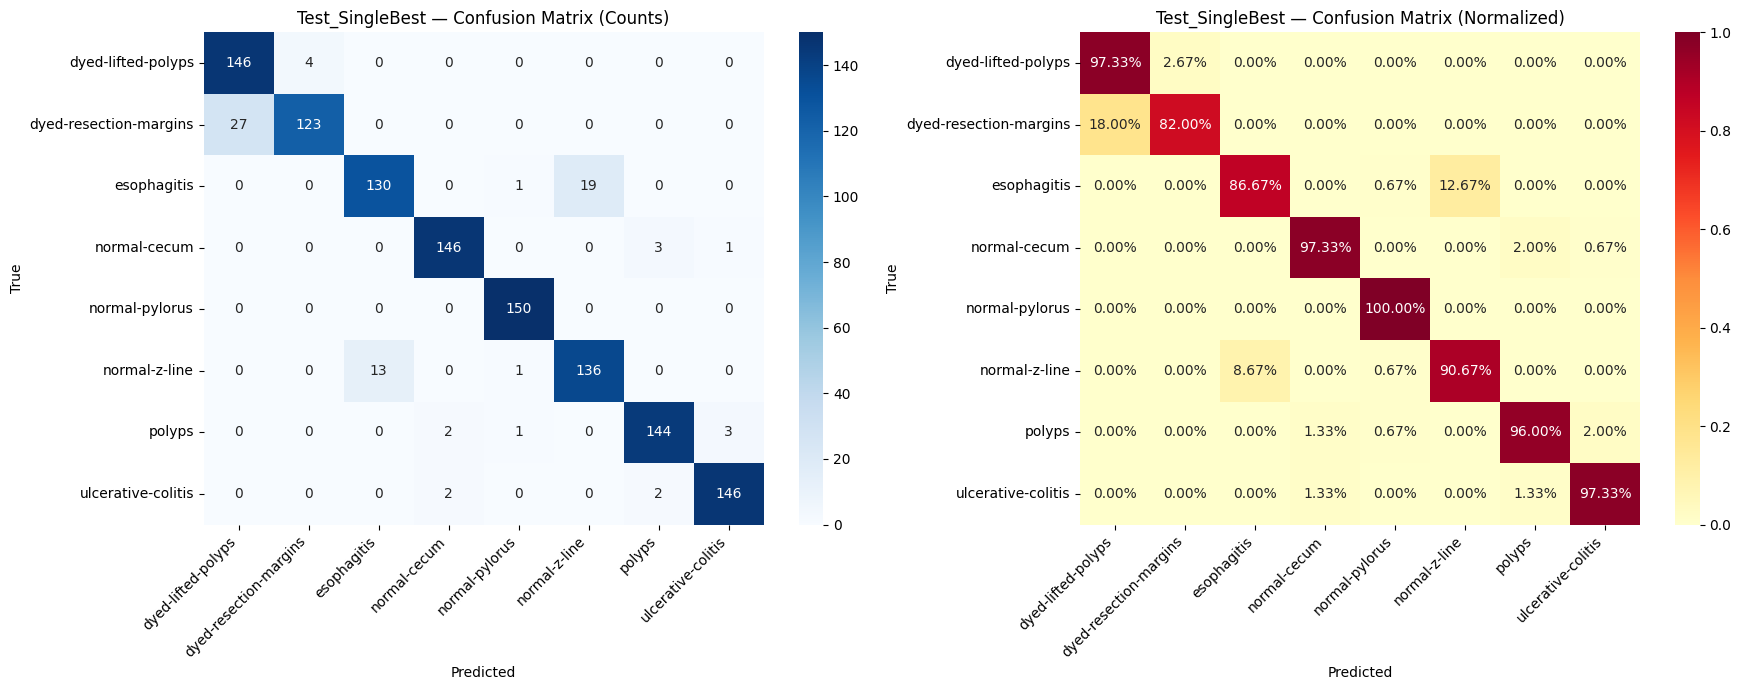

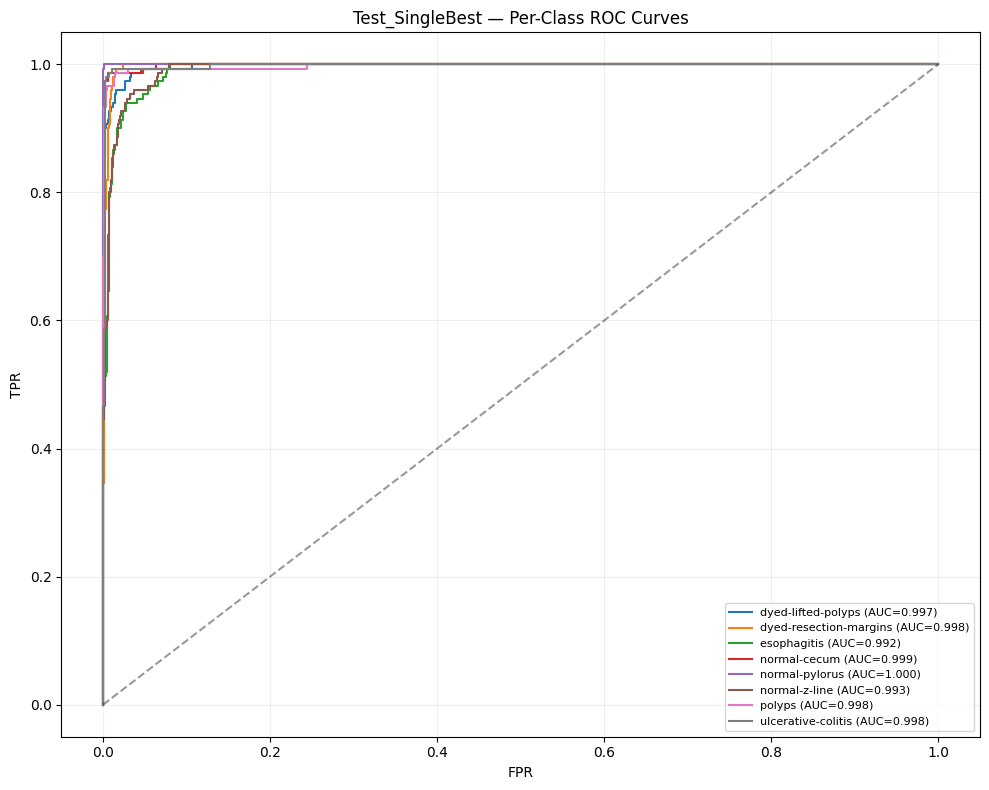

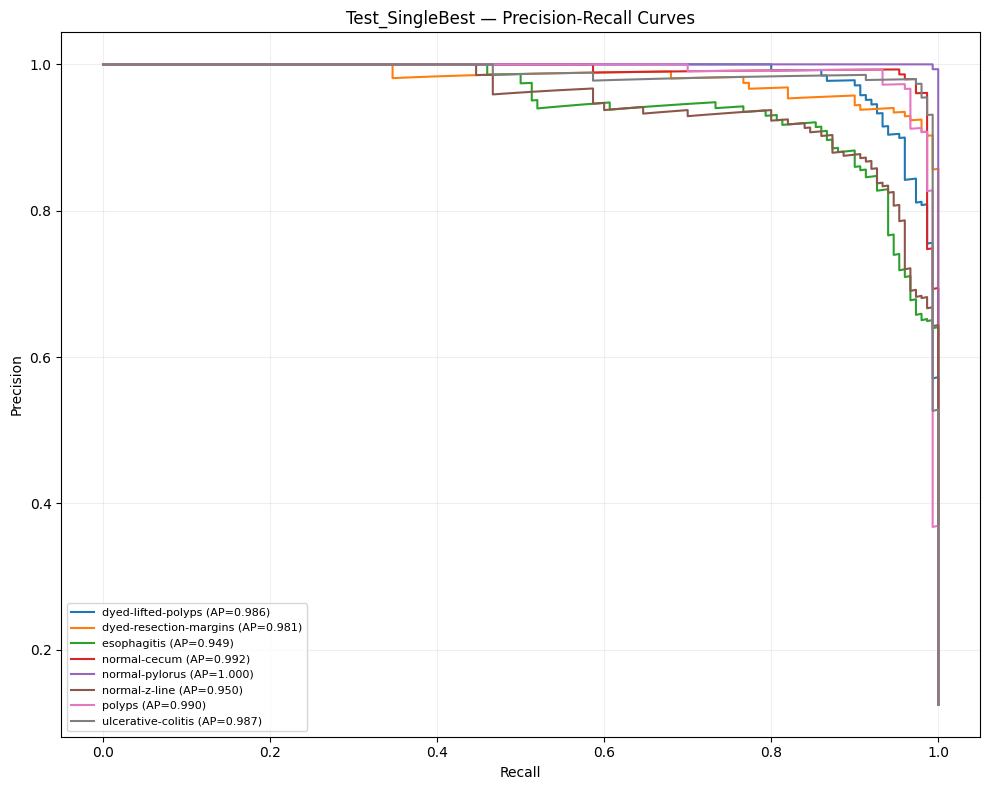

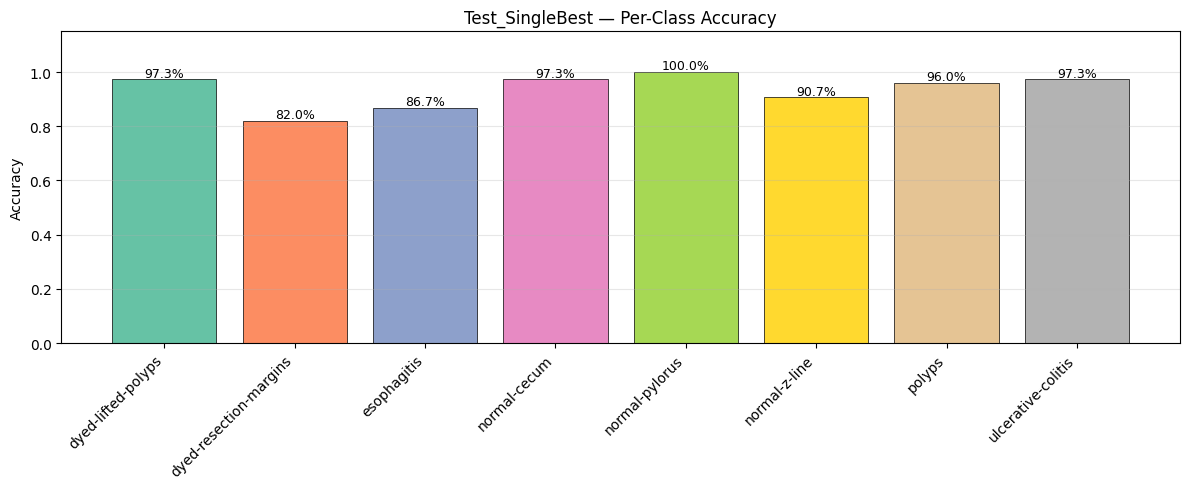

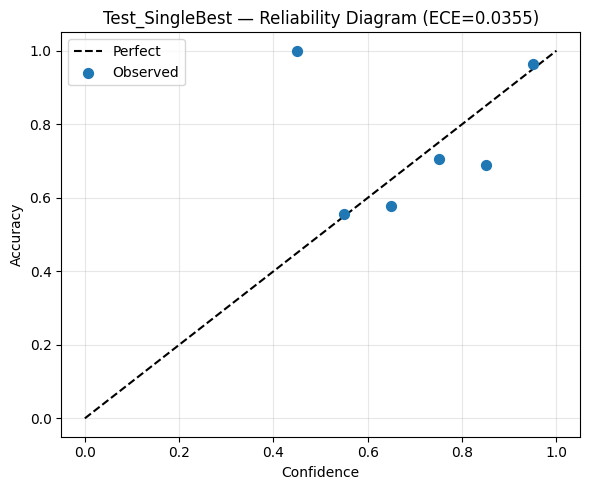

  ECE            : 0.0355

  TEST — Ensemble (5 folds, soft voting)

  Test_Ensemble — Classification Report
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.9474    0.9600    0.9536       150
dyed-resection-margins     0.9597    0.9533    0.9565       150
           esophagitis     0.9178    0.8933    0.9054       150
          normal-cecum     0.9735    0.9800    0.9767       150
        normal-pylorus     0.9934    1.0000    0.9967       150
         normal-z-line     0.8961    0.9200    0.9079       150
                polyps     0.9930    0.9467    0.9693       150
    ulcerative-colitis     0.9545    0.9800    0.9671       150

              accuracy                         0.9542      1200
             macro avg     0.9544    0.9542    0.9542      1200
          weighted avg     0.9544    0.9542    0.9542      1200

  Accuracy       : 0.9542
  Top-3 Accuracy : 1.0000
  Macro F1       : 0.9542
  Weighted F1    : 0.9542
  Cohen's Kappa 

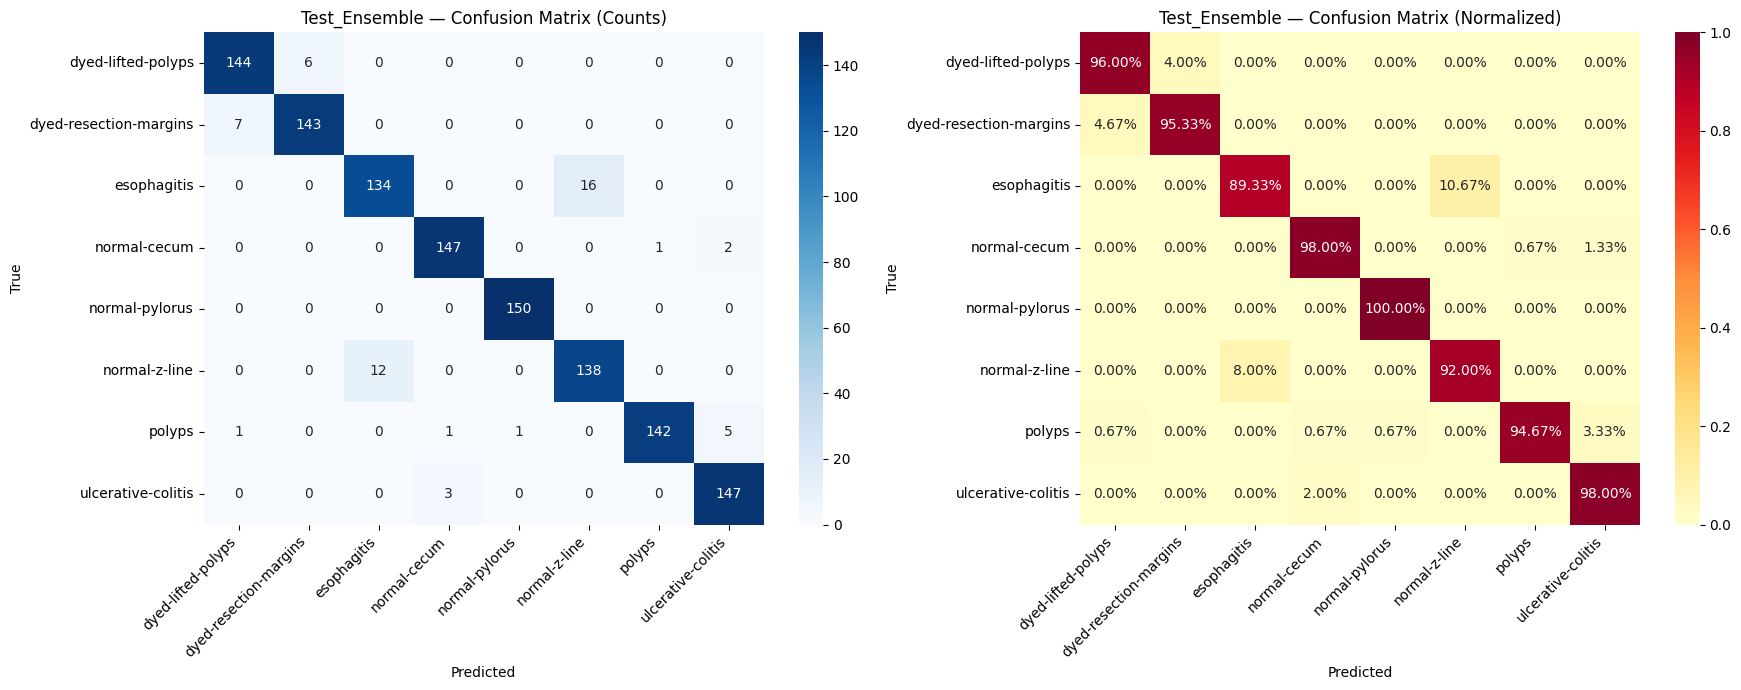

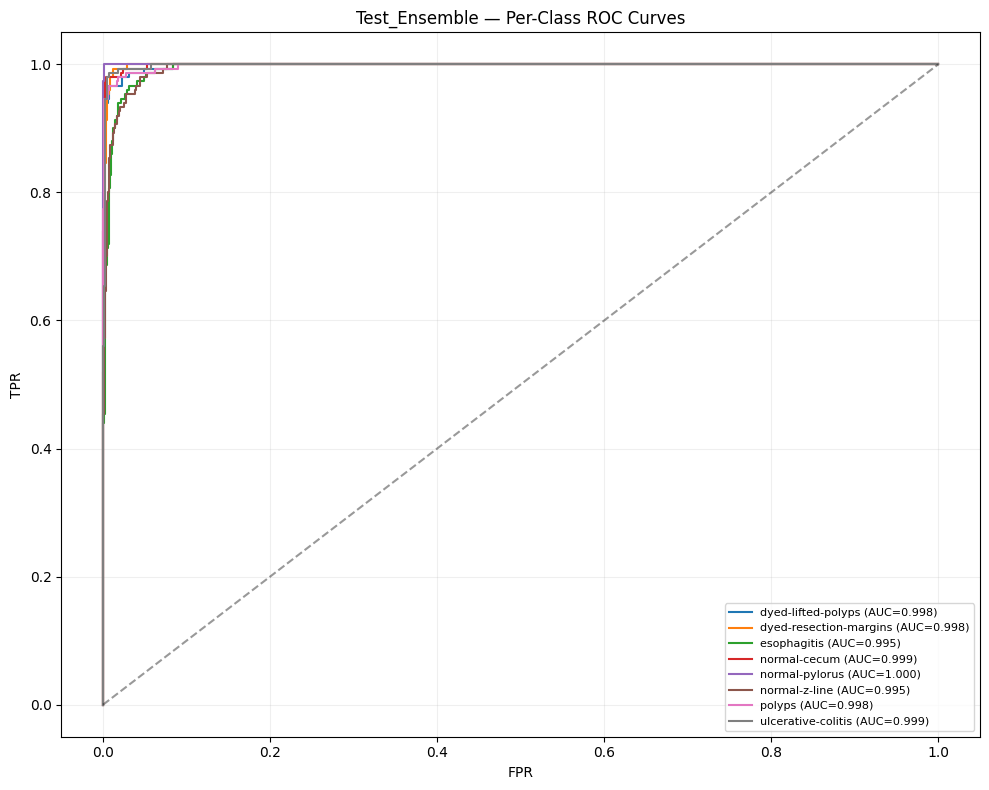

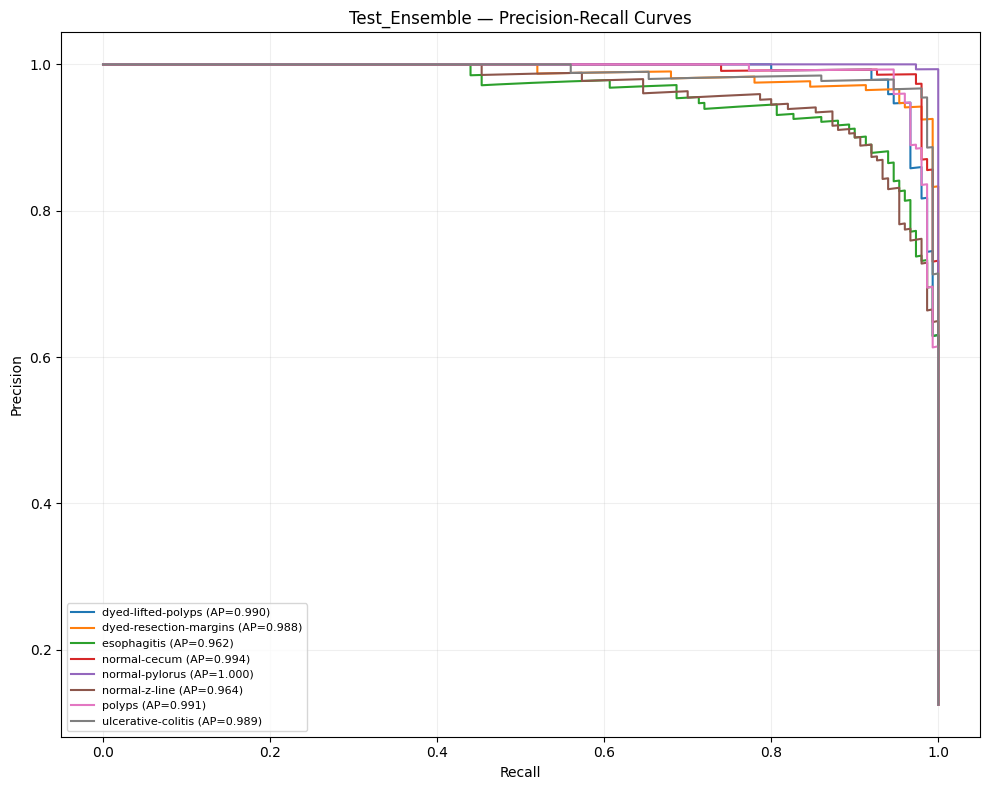

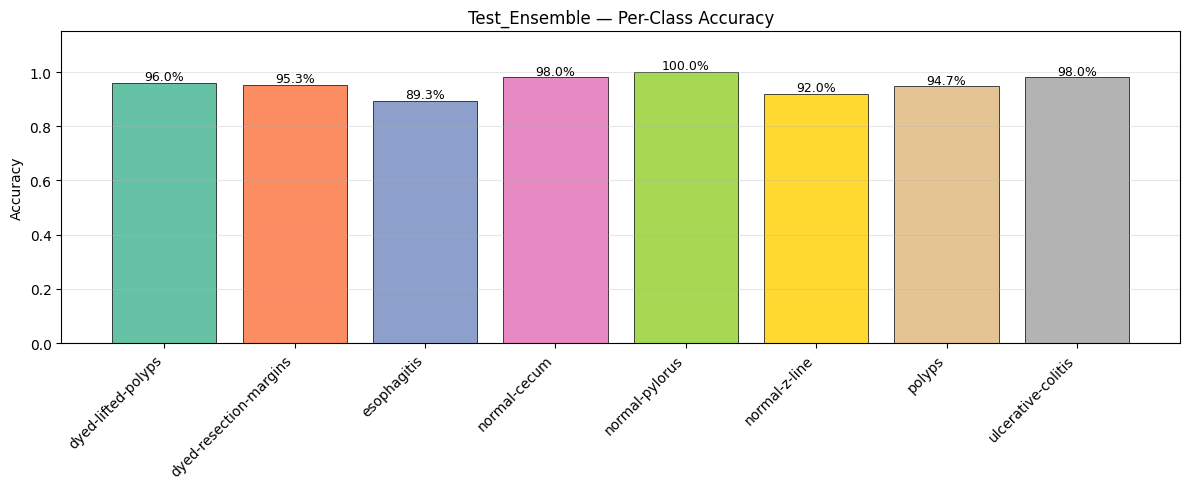

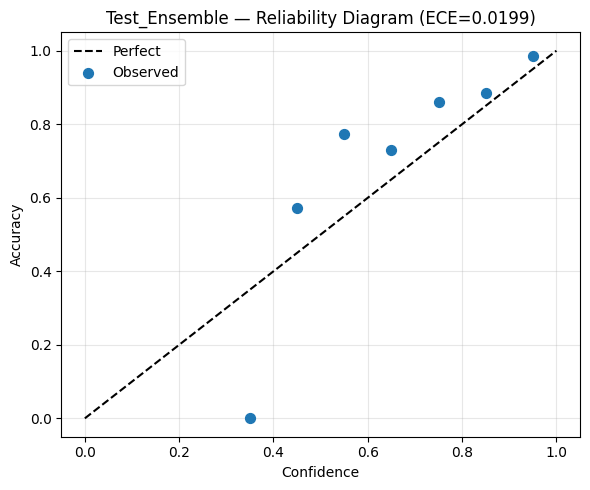

  ECE            : 0.0199


In [35]:
# ============================================================
# 12) RUN EVALUATION
# ============================================================

# Single best fold
print(f"\n{'='*65}")
print(f"  TEST — Best Single Fold ({best_fold_idx})")
print(f"{'='*65}")
single_results = full_evaluation(y_test, y_prob_single, y_pred_single, set_name="Test_SingleBest")

# Ensemble
print(f"\n{'='*65}")
print(f"  TEST — Ensemble ({len(fold_models)} folds, soft voting)")
print(f"{'='*65}")
ensemble_results = full_evaluation(y_test, y_prob_ensemble, y_pred_ensemble, set_name="Test_Ensemble")


In [36]:
# ============================================================
# 13) COMPARISON TABLE
# ============================================================
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Top-3 Accuracy", "Macro F1", "Weighted F1",
               "Cohen's Kappa", "MCC", "Macro AUC", "Weighted AUC", "ECE"],
    "Single Best": [single_results[k] for k in
        ["accuracy", "top3_accuracy", "macro_f1", "weighted_f1",
         "cohen_kappa", "mcc", "macro_auc", "weighted_auc", "ece"]],
    "Ensemble": [ensemble_results[k] for k in
        ["accuracy", "top3_accuracy", "macro_f1", "weighted_f1",
         "cohen_kappa", "mcc", "macro_auc", "weighted_auc", "ece"]],
})

print(f"\n{'='*65}")
print(f"  Single Best vs Ensemble")
print(f"{'='*65}")
print(comparison.to_string(index=False))
comparison.to_csv(os.path.join(CFG.OUTPUT_DIR, "comparison.csv"), index=False)



  Single Best vs Ensemble
        Metric  Single Best  Ensemble
      Accuracy     0.934167  0.954167
Top-3 Accuracy     0.999167  1.000000
      Macro F1     0.933908  0.954159
   Weighted F1     0.933908  0.954159
 Cohen's Kappa     0.924762  0.947619
           MCC     0.925181  0.947658
     Macro AUC     0.996833  0.997712
  Weighted AUC     0.996833  0.997712
           ECE     0.035539  0.019926


In [39]:
# ============================================================
# 14) SAVE EXPERIMENT SUMMARY
# ============================================================
summary = {
    "model": "ConvNeXt-Tiny",
    "preprocessing": "CLAHE + Gaussian + Bilateral",
    "dataset": "Kvasir v2",
    "img_size": list(CFG.IMG_SIZE),
    "batch_size": CFG.BATCH_SIZE,
    "epochs_warmup": CFG.EPOCHS_WARMUP,
    "epochs_finetune": CFG.EPOCHS_FINETUNE,
    "lr_warmup": CFG.LR_WARMUP,
    "lr_finetune": CFG.LR_FINETUNE,
    "n_folds": CFG.N_SPLITS,
    "test_size": CFG.TEST_SIZE,
    "fold_val_accuracies": val_accs,
    "mean_val_acc": float(np.mean(val_accs)),
    "std_val_acc": float(np.std(val_accs)),
    "best_single_fold": int(best_fold_idx),
    "test_single_best": {k: v for k, v in single_results.items() if k != "per_class_auc"},
    "test_ensemble": {k: v for k, v in ensemble_results.items() if k != "per_class_auc"},
}

with open(os.path.join(CFG.OUTPUT_DIR, "experiment_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=str)

with open(os.path.join(CFG.OUTPUT_DIR, "classification_report_ensemble.txt"), "w") as f:
    f.write(classification_report(y_test, y_pred_ensemble, target_names=class_names, digits=4))


print(f"\n{'='*65}")
print(f"  ALL DONE — Results saved to '{CFG.OUTPUT_DIR}/'")
print(f"{'='*65}")
print(f"\n  Files:")
print(f"    splits/                         — reproducible train/val/test CSVs")
print(f"    best_fold*.h5                   — model weights per fold")
print(f"    log_fold*.csv                   — training logs per fold")
print(f"    training_curves_all_folds.png   — loss/acc curves")
print(f"    test_*_confusion_matrix.png     — confusion matrices")
print(f"    test_*_roc_curves.png           — ROC curves")
print(f"    test_*_pr_curves.png            — precision-recall curves")
print(f"    test_*_per_class_acc.png        — per-class accuracy bars")
print(f"    test_*_calibration.png          — reliability diagrams")
print(f"    comparison.csv                  — single vs ensemble table")
print(f"    experiment_summary.json         — complete experiment config + results")
print(f"\n  Key Results:")
print(f"    CV Mean Acc      : {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"    Test Acc (single): {single_results['accuracy']:.4f}")
print(f"    Test Acc (ens.)  : {ensemble_results['accuracy']:.4f}")
print(f"    Test Macro AUC   : {ensemble_results.get('macro_auc', 'N/A')}")


  ALL DONE — Results saved to '/kaggle/working/convnext_results/'

  Files:
    splits/                         — reproducible train/val/test CSVs
    best_fold*.h5                   — model weights per fold
    log_fold*.csv                   — training logs per fold
    training_curves_all_folds.png   — loss/acc curves
    test_*_confusion_matrix.png     — confusion matrices
    test_*_roc_curves.png           — ROC curves
    test_*_pr_curves.png            — precision-recall curves
    test_*_per_class_acc.png        — per-class accuracy bars
    test_*_calibration.png          — reliability diagrams
    comparison.csv                  — single vs ensemble table
    experiment_summary.json         — complete experiment config + results

  Key Results:
    CV Mean Acc      : 0.9340 ± 0.0050
    Test Acc (single): 0.9342
    Test Acc (ens.)  : 0.9542
    Test Macro AUC   : 0.9977119047619047
